In [5]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from hmmlearn.hmm import GaussianHMM

In [20]:
np.random.seed(42) 

n_steps = 1000 

regime_means = [0.001, 0.00005, -0.002]
regime_stds = [0.03, 0.01, 0.05] 

# transition matrix: rows = current state, cols = next state 
# P
transition_matrix = np.array([
    [0.85, 0.10, 0.05],
    [0.05, 0.90, 0.05],
    [0.10, 0.10, 0.80]
])

states = np.zeros(n_steps, dtype=int) 
states[0] = 1 # initial state: calm regime 

for t in range(1, n_steps): 
    states[t] = np.random.choice(
        [0, 1, 2], 
        p=transition_matrix[states[t - 1]] 
    )

returns = np.array([
    np.random.normal(regime_means[s], regime_stds[s]) for s in states 
]) 

prices = 100 * np.cumprod(1 + returns) 
rolling_volatility = pd.DataFrame({
    "prices": prices
}).rolling(50).std() 
data = pd.DataFrame({
    "prices": prices, 
    "returns": returns,
    "rolling_std": rolling_volatility.squeeze()
})

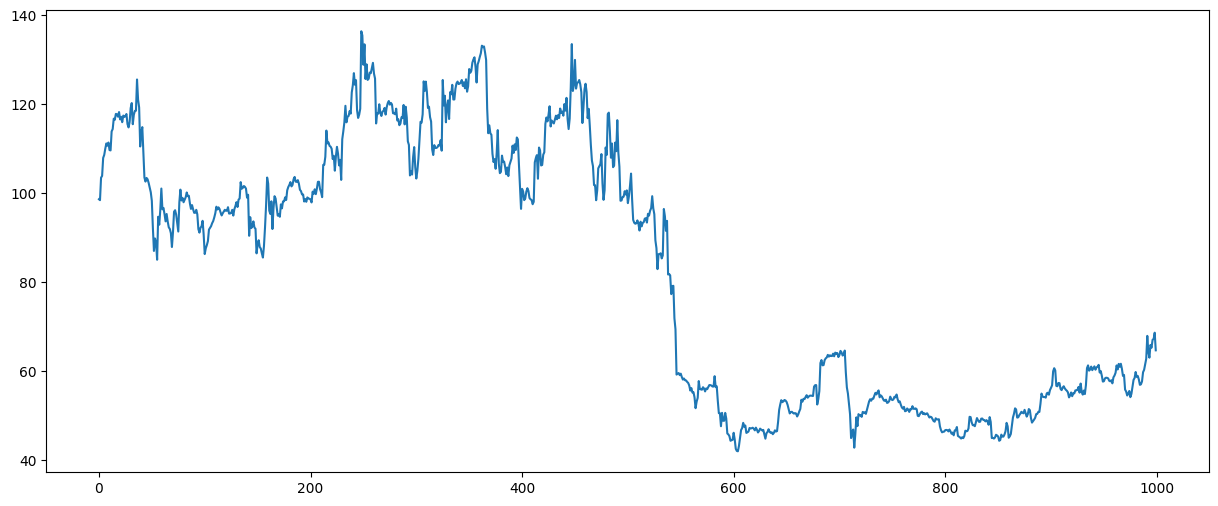

In [21]:
plt.figure(figsize=(15, 6)) 
plt.plot(prices)

In [22]:
X = data[["returns", "rolling_std"]].dropna()
model = GaussianHMM(
    n_components=3, 
    covariance_type="full",
    n_iter=100, 
    random_state=42
)

model.fit(X) 
hidden_states = model.predict(X)

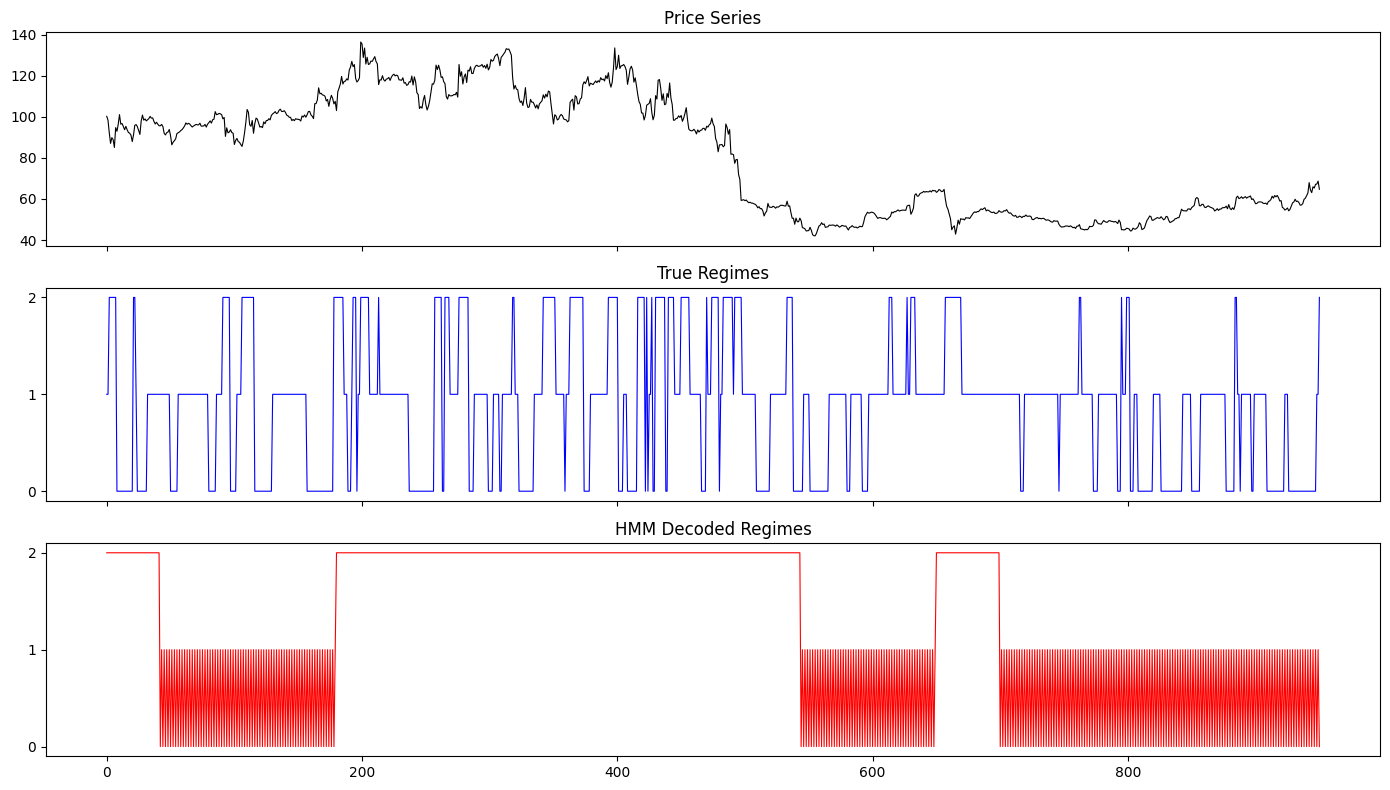

In [23]:
offset = len(prices) - len(hidden_states)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(prices[offset:], color='black', linewidth=0.8)
axes[0].set_title("Price Series")

axes[1].plot(states[offset:], color='blue', linewidth=0.8)
axes[1].set_title("True Regimes")
axes[1].set_yticks([0, 1, 2])

axes[2].plot(hidden_states, color='red', linewidth=0.8)
axes[2].set_title("HMM Decoded Regimes")
axes[2].set_yticks([0, 1, 2])

plt.tight_layout()
plt.show()